In [1]:
import os
import glob
import random

import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, random_split,Subset
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn.init as init
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

import matplotlib.pyplot as plt
from monai.losses import DiceLoss

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [3]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, padding=0):
        super().__init__()
        self.unit = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.unit(x)


In [4]:
class InceptionBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # 1x1 conv
        self.branch1 = ConvBNReLU(in_ch, out_ch, kernel_size=1)

        # 1x1 → 3x3
        self.branch2_1 = ConvBNReLU(in_ch, out_ch, kernel_size=1)
        self.branch2_2 = ConvBNReLU(out_ch, out_ch, kernel_size=3, padding=1)

        # 1x1 → 5x5
        self.branch3_1 = ConvBNReLU(in_ch, out_ch, kernel_size=1)
        self.branch3_2 = ConvBNReLU(out_ch, out_ch, kernel_size=5, padding=2)

        # AvgPool → 1x1
        self.branch4_pool = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)
        self.branch4_conv = ConvBNReLU(in_ch, out_ch, kernel_size=1)

        self.output_conv = ConvBNReLU(out_ch * 4, out_ch, kernel_size=1)

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2_2(self.branch2_1(x))
        b3 = self.branch3_2(self.branch3_1(x))
        b4 = self.branch4_conv(self.branch4_pool(x))
        concat = torch.cat([b1, b2, b3, b4], dim=1)
        return self.output_conv(concat)


In [5]:
class IUNet(nn.Module):
    def __init__(self, in_ch=1, base_filters=16):
        super().__init__()

        # Initial Conv: Conv3_32 → Conv3_32 → Conv3_64
        self.conv1 = ConvBNReLU(in_ch, base_filters, kernel_size=3, padding=1)
        self.conv2 = ConvBNReLU(base_filters, base_filters, kernel_size=3, padding=1)
        self.conv3 = ConvBNReLU(base_filters, base_filters * 2, kernel_size=3, padding=1)
        self.pool0 = nn.MaxPool2d(2)  # pool after conv3
        
        # Encoder: 5 inception + pooling
        self.enc1 = InceptionBlock(base_filters * 2, base_filters * 2)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = InceptionBlock(base_filters * 2, base_filters * 4)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = InceptionBlock(base_filters * 4, base_filters * 8)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = InceptionBlock(base_filters * 8, base_filters * 16)
        self.pool4 = nn.MaxPool2d(2)

        #self.enc5 = InceptionBlock(base_filters * 16, base_filters * 32)
        #self.pool5 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = InceptionBlock(base_filters * 16, base_filters * 16)

        # Decoder: 5 upsample + inception
        self.dec5 = InceptionBlock(base_filters*16 + base_filters*16, base_filters*16)
        self.dec4 = InceptionBlock(base_filters*16 + base_filters*8,  base_filters*8)
        self.dec3 = InceptionBlock(base_filters*8  + base_filters*4,  base_filters*4)
        self.dec2 = InceptionBlock(base_filters*4  + base_filters*2,  base_filters*2)
        self.dec1 = InceptionBlock(base_filters*2  + base_filters*2,  base_filters*2)

        # Final conv: Conv3 → Conv1
        #self.final_conv3 = ConvBNReLU(base_filters * 2, base_filters, kernel_size=3, padding=1)
        #self.final_conv1 = nn.Conv2d(base_filters, 1, kernel_size=1)

        self.final_conv3a = ConvBNReLU(base_filters*2,     base_filters*2, kernel_size=3, padding=1)  # 32→32
        self.final_conv3b = ConvBNReLU(base_filters*2,     base_filters*2, kernel_size=3, padding=1)  # 32→32
        self.final_conv3c = ConvBNReLU(base_filters*2,     base_filters*4, kernel_size=3, padding=1)  # 32→64
        self.final_conv1  = nn.Conv2d(base_filters*4, 1, kernel_size=1)                              # 64→1
        
        self.sigmoid     = nn.Sigmoid()
    def forward(self, x):
        # Initial convs
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        x3 = self.conv3(x2)
        p0 = self.pool0(x3)           # first downsample

        # Encoder
        e1 = self.enc1(p0); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        bn = self.bottleneck(p4)

        # Decoder with bilinear interpolation
        u5 = F.interpolate(bn, scale_factor=2, mode='bilinear', align_corners=False)
        d5 = self.dec5(torch.cat([u5, e4], dim=1))

        u4 = F.interpolate(d5, scale_factor=2, mode='bilinear', align_corners=False)
        d4 = self.dec4(torch.cat([u4, e3], dim=1))

        u3 = F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([u3, e2], dim=1))

        u2 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([u2, e1], dim=1))

        u1 = F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([u1, x3], dim=1))

        out = self.final_conv3a(d1)   # 32→32
        out = self.final_conv3b(out)  # 32→32
        out = self.final_conv3c(out)  # 32→64
        out = self.final_conv1(out)   # 64→1
        return out

In [6]:
class SegmentationDataset(Dataset):
    def __init__(self, folder, img_size=(64,64), augment=False):
        all_imgs = sorted(glob.glob(os.path.join(folder, '*.tif')))
        self.samples = []
        for img_path in all_imgs:
            base, ext = os.path.splitext(img_path)
            mask_path = base + '_mask' + ext
            if os.path.exists(mask_path):
                self.samples.append((img_path, mask_path))
        if not self.samples:
            raise RuntimeError(f"No image/mask pairs in {folder}")

        self.img_size = img_size
        self.augment  = augment
        self.clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img  = cv2.imread(img_path,  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        img  = cv2.resize(img,  self.img_size)
        mask = cv2.resize(mask, self.img_size)

        # CLAHE + normalize
        img  = self.clahe.apply(img) / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.augment:
            # flip
            if random.random() < 0.5:
                img, mask = np.fliplr(img), np.fliplr(mask)
            # rotate ±15°
            angle = random.uniform(-15,15)
            M = cv2.getRotationMatrix2D((self.img_size[0]//2, self.img_size[1]//2), angle, 1)
            img  = cv2.warpAffine(img,  M, self.img_size)
            mask = cv2.warpAffine(mask, M, self.img_size)
            # gaussian noise
            img  = np.clip(img + np.random.randn(*img.shape)*0.05, 0, 1)

        img  = torch.from_numpy(img).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return img, mask


In [7]:
def get_loaders_by_patient(
    base_folder,
    batch_size: int = 30,
    img_size: tuple = (64, 64),
    num_workers: int = 4
):
    # 1) Define your patient sets
    test_ids = {44, 45, 46, 47}
    val_ids  = {36, 37, 38, 39, 40, 41, 42, 43}
    # train_ids will be "all others"

    # 2) Build the full dataset
    ds_full = SegmentationDataset(
        base_folder,
        img_size=img_size,
        augment=False      # we'll turn it on for train subset only
    )

    # 3) Partition indices by patient
    train_idx, val_idx, test_idx = [], [], []
    for i, (img_path, mask_path) in enumerate(ds_full.samples):
        pid = int(os.path.basename(img_path).split('_')[0])
        if pid in test_ids:
            test_idx.append(i)
        elif pid in val_ids:
            val_idx.append(i)
        else:
            train_idx.append(i)

    # 4) Create Subsets
    ds_train = Subset(ds_full, train_idx)
    ds_val   = Subset(ds_full, val_idx)
    ds_test  = Subset(ds_full, test_idx)

    # 5) Turn on augmentation only for training
    ds_train.dataset.augment = True

    # 6) Wrap in DataLoaders
    return {
        'train': DataLoader(
            ds_train,
            batch_size=batch_size,
            shuffle=True,
            pin_memory=True,
            num_workers=num_workers
        ),
        'val': DataLoader(
            ds_val,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=num_workers
        ),
        'test': DataLoader(
            ds_test,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True,
            num_workers=num_workers
        ),
    }

In [8]:
# Weight init: Xavier normal
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

#  Dice loss (negative coefficient)
def dice_loss(pred, target, eps=1e-6):
    # pred: [B,1,H,W] after sigmoid, target: [B,1,H,W]
    pred_flat   = pred.flatten(2)   # [B,1,N]
    target_flat = target.flatten(2) # [B,1,N]
    num = 2 * (pred_flat * target_flat).sum(-1)  # [B,1]
    den = (pred_flat**2).sum(-1) + (target_flat**2).sum(-1)  # [B,1]
    per_sample = 1 - (num + eps) / (den + eps)  # [B,1]
    return per_sample.mean()  # <-- mean over batch, scalar


def dice_coeff(pred, target, eps=1e-6):
    pred_flat   = pred.flatten(2)
    target_flat = target.flatten(2)
    num = 2 * (pred_flat * target_flat).sum(-1)
    den = (pred_flat**2).sum(-1) + (target_flat**2).sum(-1)
    return ((num + eps) / (den + eps)).mean().item()
    
#  Setup
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_folder = "/mnt/e/Mahban/Nerve/DL_Spring_2025/ultrasound-nerve-segmentation_raw_OnlyNerve/train"
loaders = get_loaders_by_patient(
    base_folder,
    batch_size=30,
    img_size=(64,64),
    num_workers=4
)

model      = IUNet(in_ch=1, base_filters=16).to(device)
model.apply(init_weights)

optimizer  = optim.Adam(model.parameters(),
                        lr=1e-4,
                        betas=(0.9, 0.999))

num_epochs = 50
best_val   = float('inf')

history = {
    'train_loss': [],
    'val_loss':   [],
    'train_dice': [],
    'test_dice':  []
}

#  Training loop
for epoch in range(1, num_epochs + 1):
    # -- Train --
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    for x, y in tqdm(loaders['train'], desc=f"[Epoch {epoch:02d}] Train"):
        x, y = x.to(device), y.to(device).float()
        optimizer.zero_grad()
        preds = torch.sigmoid(model(x))
        loss  = dice_loss(preds, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_coeff(preds, y)

    history['train_loss'].append(running_loss / len(loaders['train']))
    history['train_dice'].append(running_dice / len(loaders['train']))

    # -- Validation --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in loaders['val']:
            x, y  = x.to(device), y.to(device).float()
            preds = torch.sigmoid(model(x))
            val_loss += dice_loss(preds, y).item()

    history['val_loss'].append(val_loss / len(loaders['val']))

    # -- Test (for monitoring) --
    test_dice = 0.0
    with torch.no_grad():
        for x, y in loaders['test']:
            x, y   = x.to(device), y.to(device).float()
            preds  = torch.sigmoid(model(x))
            test_dice += dice_coeff(preds, y)

    history['test_dice'].append(test_dice / len(loaders['test']))

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {history['train_loss'][-1]:.4f} "
        f"Train Dice: {history['train_dice'][-1]:.4f} | "
        f"Val Loss: {history['val_loss'][-1]:.4f} "
        f"Test Dice: {history['test_dice'][-1]:.4f}"
    )



[Epoch 01] Train: 100%|█████████████████████████████████████████████████████████████████| 57/57 [00:30<00:00,  1.84it/s]


Epoch 01 | Train Loss: 0.7816 Train Dice: 0.2184 | Val Loss: 0.7135 Test Dice: 0.2834


[Epoch 02] Train: 100%|█████████████████████████████████████████████████████████████████| 57/57 [00:16<00:00,  3.56it/s]


Epoch 02 | Train Loss: 0.5224 Train Dice: 0.4776 | Val Loss: 0.5055 Test Dice: 0.5170


[Epoch 03] Train: 100%|█████████████████████████████████████████████████████████████████| 57/57 [00:16<00:00,  3.52it/s]


...

Epoch 48 | Train Loss: 0.1309 Train Dice: 0.8691 | Val Loss: 0.2079 Test Dice: 0.6656


[Epoch 49] Train: 100%|█████████████████████████████████████████████████████████████████| 57/57 [00:15<00:00,  3.69it/s]


Epoch 49 | Train Loss: 0.1288 Train Dice: 0.8712 | Val Loss: 0.2084 Test Dice: 0.6797


[Epoch 50] Train: 100%|█████████████████████████████████████████████████████████████████| 57/57 [00:15<00:00,  3.69it/s]


Epoch 50 | Train Loss: 0.1218 Train Dice: 0.8782 | Val Loss: 0.2011 Test Dice: 0.6788


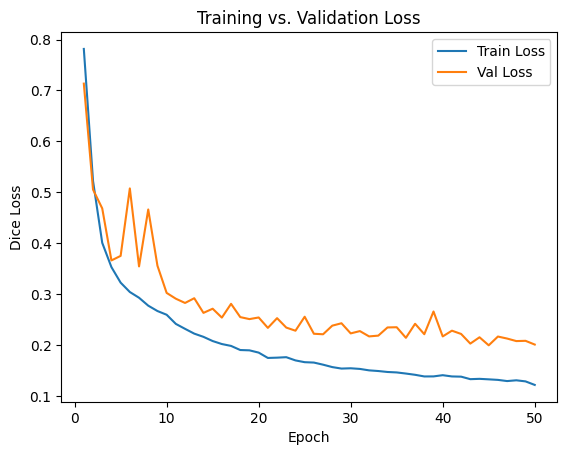

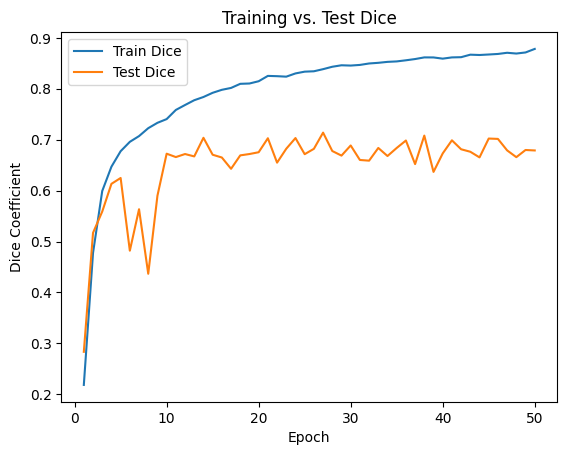

In [9]:
# 5) Plotting
epochs = range(1, num_epochs + 1)

# Loss: train vs. val
plt.figure()
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Dice Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

# Dice: train vs. test
plt.figure()
plt.plot(epochs, history['train_dice'], label='Train Dice')
plt.plot(epochs, history['test_dice'],  label='Test Dice')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Training vs. Test Dice')
plt.legend()
plt.show()